# **Deepfake Image Detection Using Convolutional Neural Network (CNN)**

## **Indroduction**

With the development of Artificial Intelligence, it has become possible to create highly realistic fake images using deep learning techniques. These AI-generated images are called deepfakes. Deepfake images can be misused for spreading false information, identity theft, and digital fraud.
This project focuses on developing a Deep Learning-based Deepfake Detection System that can automatically identify whether an image is real or fake.
The system uses a Convolutional Neural Network (CNN) because CNNs are highly effective for image processing and can learn important visual features from images.

# **Objective of the Project**

The objective of this project is to design and implement a CNN-based deep learning model for detecting deepfake images. The model learns features from real and fake image datasets and classifies unseen images as authentic or manipulated. The system aims to improve the reliability of digital content verification using artificial intelligence.

In [ ]:
# Connect Google Drive

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

path = "/content/drive/MyDrive/Deepfake_Project/rvf10k"

print(os.listdir(path))

['valid', 'train']


## **IMPORT LIBRARIES**

In [ ]:
# Import required libraries

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

## **DATA** **PREPROCESSING**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_path = "/content/drive/MyDrive/Deepfake_Project/rvf10k/train"

valid_path = "/content/drive/MyDrive/Deepfake_Project/rvf10k/valid"


train_datagen = ImageDataGenerator

    rescale=1./255

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True

)


valid_datagen = ImageDataGenerator(

    rescale=1./255

)

In [ ]:
#loading image
train_data = train_datagen.flow_from_directory(

    train_path,

    target_size=(224,224),

    batch_size=32,

    class_mode="binary"

)


valid_data = valid_datagen.flow_from_directory(

    valid_path,

    target_size=(224,224),

    batch_size=32,

    class_mode="binary"

)

Found 7007 images belonging to 2 classes.
Found 3000 images belonging to 2 classes.


7007 images were used to train the CNN model and 3000 images were used to validation that evaluate the model performence on an unseen images

## **BUILD** **CNN** **ARCHITECTURE**

In [ ]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


model = Sequential()


# First convolution layer
model.add(
Conv2D(32,(3,3),
activation="relu",
input_shape=(224,224,3))
)


# Reduce image size
model.add(MaxPooling2D(2,2))


# Second convolution layer
model.add(
Conv2D(64,(3,3),
activation="relu")
)


model.add(MaxPooling2D(2,2))


# Convert features into vector
model.add(Flatten())


# Fully connected layer
model.add(Dense(128,activation="relu"))


# Prevent overfitting
model.add(Dropout(0.5))


# Output layer
model.add(Dense(1,activation="sigmoid"))


model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,521 (91.20 MB)

 Trainable params: 23,907,521 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

## **TRAIN** **MODEL**

In [ ]:
model.compile(

optimizer="adam",

loss="binary_crossentropy",

metrics=["accuracy"]

)

In [ ]:

history = model.fit(

train_data,

validation_data=valid_data,

epochs=25

)

Epoch 1/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 4077s 19s/step - accuracy: 0.5329 - loss: 0.7779 - val_accuracy: 0.5817 - val_loss: 0.6753
Epoch 2/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 131s 598ms/step - accuracy: 0.5837 - loss: 0.6778 - val_accuracy: 0.6137 - val_loss: 0.6558
Epoch 3/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 132s 599ms/step - accuracy: 0.6171 - loss: 0.6573 - val_accuracy: 0.6313 - val_loss: 0.6429
Epoch 4/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 132s 600ms/step - accuracy: 0.6271 - loss: 0.6514 - val_accuracy: 0.6557 - val_loss: 0.6241
Epoch 5/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 129s 592ms/step - accuracy: 0.6412 - loss: 0.6351 - val_accuracy: 0.6530 - val_loss: 0.6325
Epoch 6/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 130s 594ms/step - accuracy: 0.6426 - loss: 0.6380 - val_accuracy: 0.6710 - val_loss: 0.6057
Epoch 7/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 130s 595ms/step - accuracy: 0.6486 - loss: 0.6278 - val_accuracy: 0.6717 - val_loss: 0.6101
Epoch 8/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 132s 604ms/step - accuracy: 0.6655 - 

Training accuracy =0.7400(74%)
validation accuracy=0.7310(73.10%)
both are close value so model is not heavily overfitting


In [ ]:
model.save("/content/drive/MyDrive/Deepfake_Project/deepfake_cnn_model.h5")

## **EVALUATE** **CNN** **MODEL**

In [ ]:
# Evaluate model performance

loss, accuracy = model.evaluate(valid_data)

print("Validation Accuracy:", accuracy)
print("Validation Loss:", loss)

94/94 ━━━━━━━━━━━━━━━━━━━━ 21s 227ms/step - accuracy: 0.7310 - loss: 0.5282
Validation Accuracy: 0.7310000061988831
Validation Loss: 0.5281948447227478


### **Plot accuracy graph**

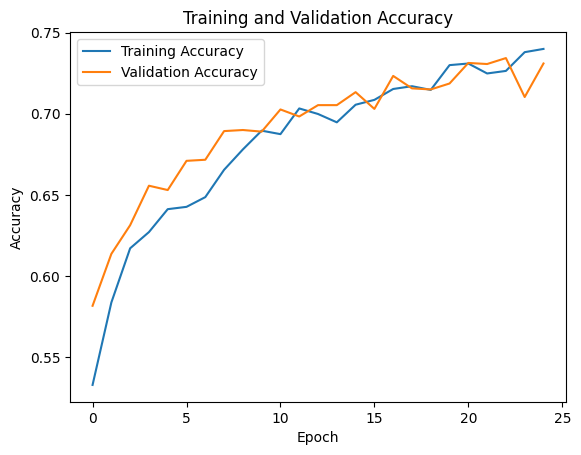

In [ ]:
import matplotlib.pyplot as plt


# Accuracy graph

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Training Accuracy",
            "Validation Accuracy"])

plt.title("Training and Validation Accuracy")

plt.show()

### **Plot loss graph**

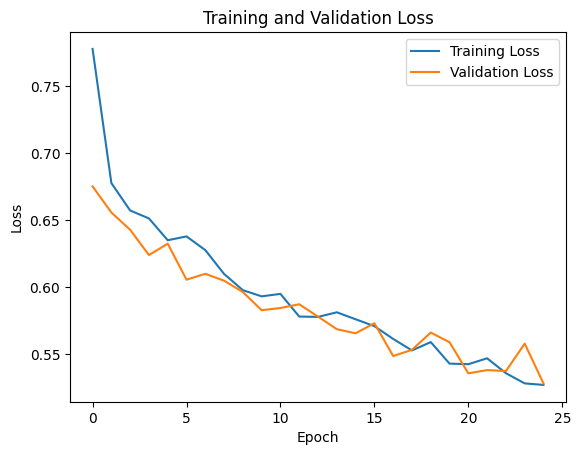

In [ ]:
# Loss graph

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Training Loss",
            "Validation Loss"])

plt.title("Training and Validation Loss")

plt.show()

### **Classification reports**

In [ ]:
# Reload validation data without shuffling

valid_data = valid_datagen.flow_from_directory(

    valid_path,

    target_size=(224,224),

    batch_size=32,

    class_mode="binary",

    shuffle=False
)

Found 3000 images belonging to 2 classes.


In [ ]:
# Predict validation images

predictions = model.predict(valid_data)
# Evaluate model performance

loss, accuracy = model.evaluate(valid_data)


# Convert probabilities to classes

predicted_classes = (predictions > 0.5).astype(int)

94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 130ms/step


In [ ]:
from sklearn.metrics import classification_report

true_classes = valid_data.classes

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=["Fake","Real"]
    )
)

              precision    recall  f1-score   support

        Fake       0.75      0.70      0.72      1500
        Real       0.72      0.76      0.74      1500

    accuracy                           0.73      3000
   macro avg       0.73      0.73      0.73      3000
weighted avg       0.73      0.73      0.73      3000



### **Confusion Metrix**

In [ ]:
# Get true labels and predictions

true_classes = valid_data.classes

predictions = model.predict(valid_data)

predicted_classes = (predictions > 0.5).astype(int)

94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 128ms/step


[[1053  447]
 [ 360 1140]]


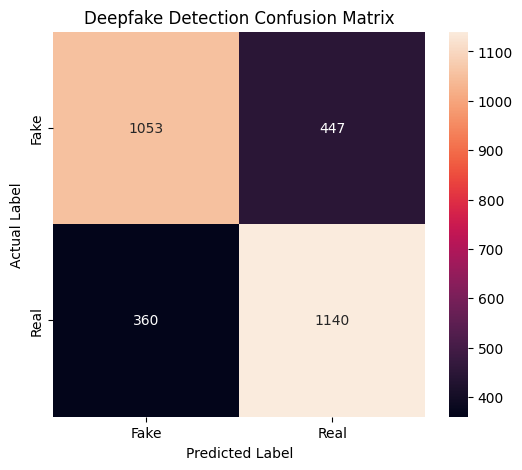

In [ ]:

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Create confusion matrix

cm = confusion_matrix(
    true_classes,
    predicted_classes
)


print(cm)


# Display confusion matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Fake","Real"],
    yticklabels=["Fake","Real"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Deepfake Detection Confusion Matrix")

plt.show()

"The confusion matrix contains the prediction results of 3000 validation images. Out of 1500 fake images, the CNN correctly identified 1053 images and misclassified 447 images as real. Out of 1500 real images, the model correctly identified 1140 images and classified 360 images incorrectly as fake. The total correct predictions are 2193 out of 3000 images, which gives a validation accuracy of 73.10%."

### **Test new image Prediction**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving realistic-beautiful-girl-standing-on-the-street-generated-by-Fotor-ai.jpg to realistic-beautiful-girl-standing-on-the-street-generated-by-Fotor-ai.jpg


In [ ]:
# Import required libraries

import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

**load** **trained** **CNN** **model**

In [ ]:
# Load saved CNN model

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/Deepfake_Project/deepfake_cnn_model.h5"
)

print("Model loaded successfully")

Model loaded successfully


In [ ]:
# Image path

img_path = "realistic-beautiful-girl-standing-on-the-street-generated-by-Fotor-ai.jpg"

In [ ]:
# Resize and normalize image

img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)

# Convert pixels from 0-255 to 0-1
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

print("Image prepared successfully")

Image prepared successfully


### **Predict real or fake**

In [ ]:
# Make prediction

prediction = model.predict(img_array)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 928ms/step
[[0.98449594]]


**Convert prediction into result**

In [ ]:
# Display final result

if prediction[0][0] < 0.5:
    print("Prediction: Fake Image")
else:
    print("Prediction: Real Image")

Prediction: Fake Image


**Display uploaded image**

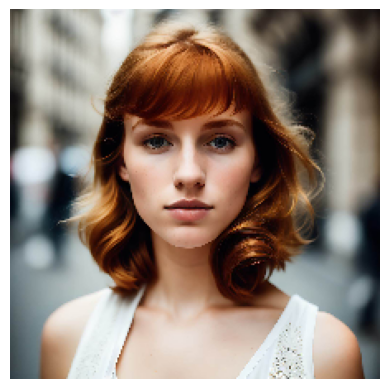

In [ ]:
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
model.save("deepfake_detector.keras")

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("deepfake_detector.keras")

print("Model loaded successfully")

Model loaded successfully


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 18 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,722,565 (273.60 MB)

 Trainable params: 23,907,521 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 47,815,044 (182.40 MB)

In [ ]:
from google.colab import files

files.download("deepfake_detector.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model.save("/content/drive/MyDrive/deepfake_detector.keras")